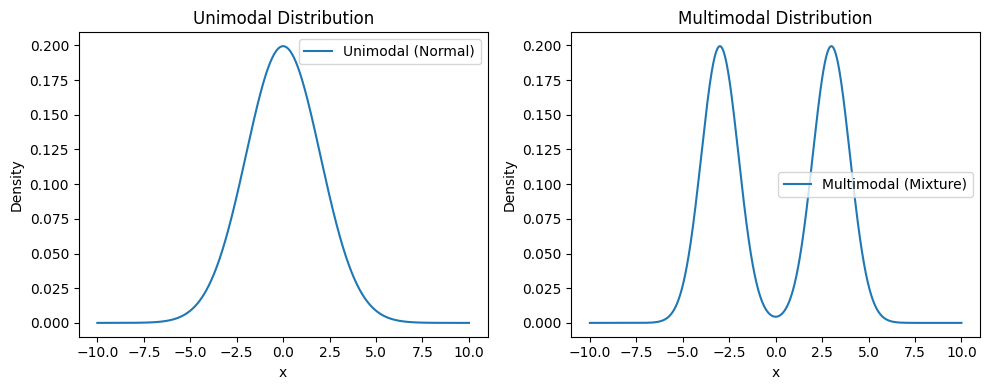

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
x = np.linspace(-10, 10, 1000)
# Unimodal: Normal distribution
mu, sigma = 0, 2
unimodal = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x, unimodal, label='Unimodal (Normal)')
plt.title('Unimodal Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
# Multimodal: Mixture of two Gaussians
mu1, sigma1, w1 = -3, 1, 0.5
mu2, sigma2, w2 = 3, 1, 0.5
multimodal = w1 * norm.pdf(x, mu1, sigma1) + w2 * norm.pdf(x, mu2, sigma2)
plt.subplot(1, 2, 2)
plt.plot(x, multimodal, label='Multimodal (Mixture)')
plt.title('Multimodal Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

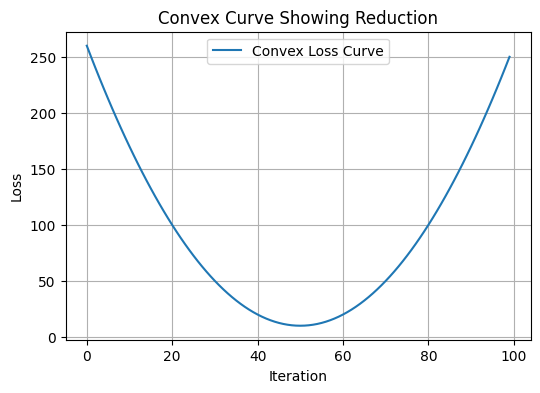

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Example: Convex loss curve decreasing over iterations
iterations = np.arange(0, 100)
loss = 0.1 * (iterations - 50)**2 + 10
loss = np.maximum(loss, 0)
plt.figure(figsize=(6, 4))
plt.plot(iterations, loss, label='Convex Loss Curve')
plt.title('Convex Curve Showing Reduction')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

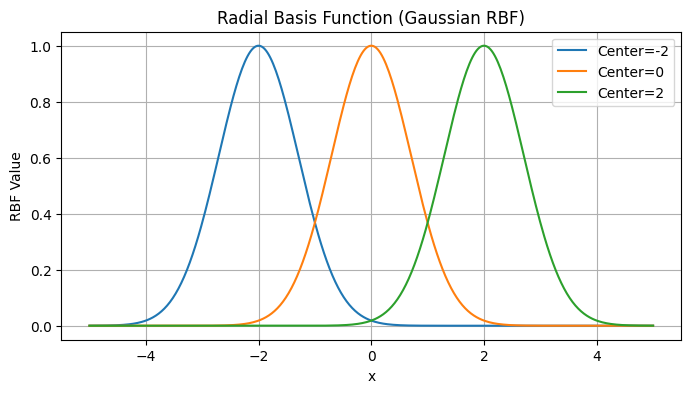

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# Radial Basis Function (Gaussian RBF)
def rbf(x, c=0, gamma=1):
    return np.exp(-gamma * (x - c)**2)
x = np.linspace(-5, 5, 400)
centers = [-2, 0, 2]
gamma = 1
plt.figure(figsize=(8, 4))
for c in centers:
    plt.plot(x, rbf(x, c, gamma), label=f'Center={c}')
plt.title('Radial Basis Function (Gaussian RBF)')
plt.xlabel('x')
plt.ylabel('RBF Value')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
# Example: Multi-task learning model with two outputs
class MultiTaskNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.regression_head = nn.Linear(16, 1)
        self.classification_head = nn.Linear(16, 2)
    def forward(self, x):
        features = self.shared(x)
        reg_out = self.regression_head(features)
        class_out = self.classification_head(features)
        return reg_out, class_out
# Dummy data
X = torch.randn(100, 10)
y_reg = torch.randn(100, 1)
y_class = torch.randint(0, 2, (100,))
# Model, loss, optimizer
model = MultiTaskNet()
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_reg = nn.MSELoss()
loss_class = nn.CrossEntropyLoss()
# Training loop (one epoch)
model.train()
for i in range(100):
    optimizer.zero_grad()
    reg_out, class_out = model(X)
    l1 = loss_reg(reg_out, y_reg)
    l2 = loss_class(class_out, y_class)
    loss = l1 + l2
    loss.backward()
    optimizer.step()
print('Multi-task learning example: regression and classification losses combined.')

/media/guru/e3dd0686-a58b-467b-913b-60b095056804/Deep_Gen_AI/lib/python3.10/site-packages/torch/autograd/graph.py:829: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Multi-task learning example: regression and classification losses combined.


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
# Simple demonstration of meta-learning (MAML concept)
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 1)
    def forward(self, x):
        return self.fc(x)
# Simulate two tasks: y = ax + b with different a, b
def get_task(a, b):
    x = torch.linspace(-1, 1, 10).unsqueeze(1)
    y = a * x + b
    return x, y
# Meta-learning loop (simplified)
meta_model = SimpleNet()
meta_optimizer = optim.SGD(meta_model.parameters(), lr=0.01)
meta_steps = 5
for meta_step in range(meta_steps):
    meta_optimizer.zero_grad()
    meta_loss = 0
    # Sample tasks
    for a, b in [(2, 1), (-1, 0.5)]:
        x, y = get_task(a, b)
        # Clone model for fast adaptation
        fast_model = SimpleNet()
        fast_model.load_state_dict(meta_model.state_dict())
        fast_optimizer = optim.SGD(fast_model.parameters(), lr=0.1)
        # Inner loop: fast adaptation
        for _ in range(3):
            fast_optimizer.zero_grad()
            loss = nn.MSELoss()(fast_model(x), y)
            loss.backward()
            fast_optimizer.step()
        # Compute meta-loss on adapted model
        meta_loss += nn.MSELoss()(fast_model(x), y)
    meta_loss.backward()
    meta_optimizer.step()
    print(f'Meta step {meta_step+1}, meta-loss: {meta_loss.item():.4f}')
print('Meta-learning (MAML) demo: model learns to adapt quickly to new tasks.')

Meta step 1, meta-loss: 1.4853
Meta step 2, meta-loss: 1.4853
Meta step 3, meta-loss: 1.4853
Meta step 4, meta-loss: 1.4853
Meta step 5, meta-loss: 1.4853
Meta-learning (MAML) demo: model learns to adapt quickly to new tasks.


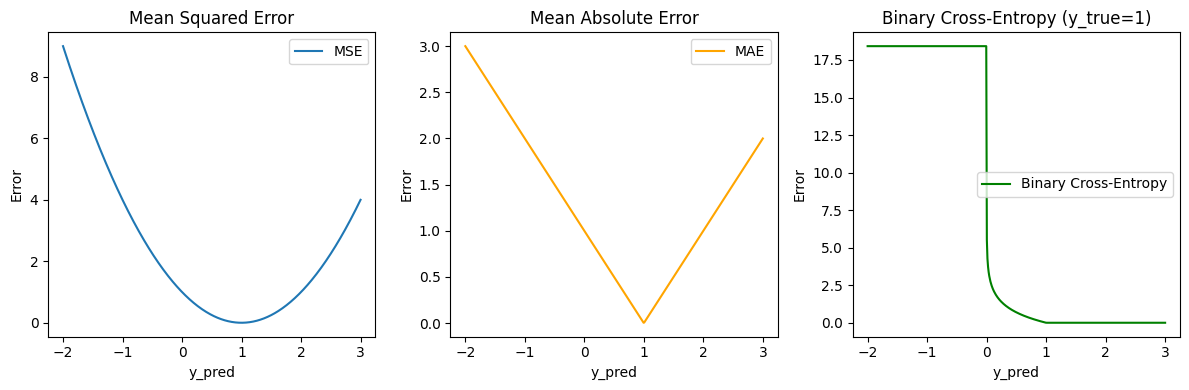

In [6]:
import numpy as np
import matplotlib.pyplot as plt
# Error functions: MSE, MAE, Cross-Entropy
y_true = 1
y_pred = np.linspace(-2, 3, 500)
# Mean Squared Error (MSE)
mse = (y_pred - y_true)**2
# Mean Absolute Error (MAE)
mae = np.abs(y_pred - y_true)
# Binary Cross-Entropy (for y_true=1)
eps = 1e-8
bce = -np.log(np.clip(y_pred, eps, 1))
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(y_pred, mse, label='MSE')
plt.title('Mean Squared Error')
plt.xlabel('y_pred')
plt.ylabel('Error')
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(y_pred, mae, label='MAE', color='orange')
plt.title('Mean Absolute Error')
plt.xlabel('y_pred')
plt.ylabel('Error')
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(y_pred, bce, label='Binary Cross-Entropy', color='green')
plt.title('Binary Cross-Entropy (y_true=1)')
plt.xlabel('y_pred')
plt.ylabel('Error')
plt.legend()
plt.tight_layout()
plt.show()

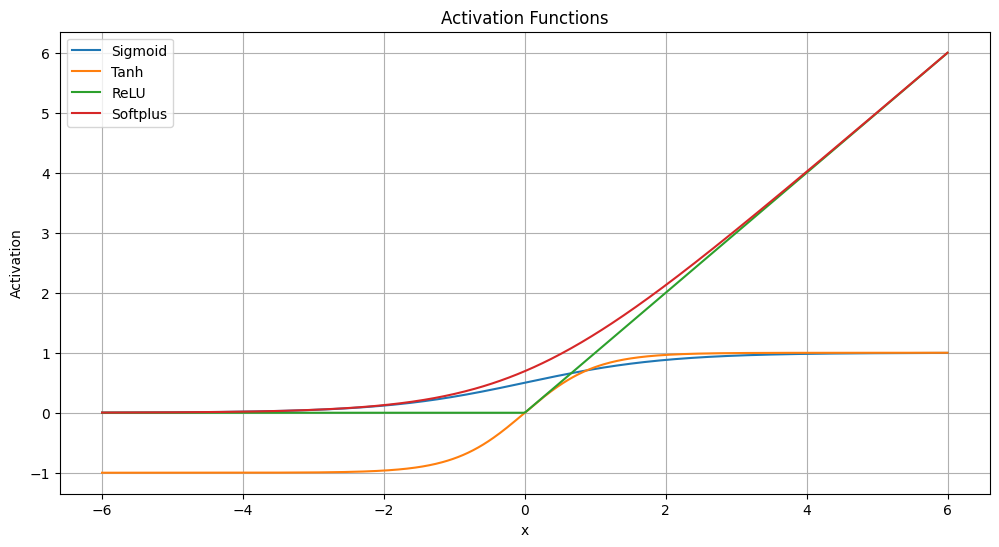

In [7]:
import numpy as np
import matplotlib.pyplot as plt
# Common activation functions
x = np.linspace(-6, 6, 500)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)
softplus = np.log(1 + np.exp(x))
plt.figure(figsize=(12, 6))
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')
plt.plot(x, relu, label='ReLU')
plt.plot(x, softplus, label='Softplus')
plt.title('Activation Functions')
plt.xlabel('x')
plt.ylabel('Activation')
plt.legend()
plt.grid(True)
plt.show()

# Difference and Use of Unimodal vs Multimodal Distributions
**Unimodal Distribution:**
- Has a single peak (mode) in its probability density function.
- Example: Normal (Gaussian) distribution.
- Used when data is expected to cluster around a single value or mean.
- Common in natural phenomena, measurement errors, and simple models.

**Multimodal Distribution:**
- Has two or more peaks (modes) in its probability density function.
- Example: Mixture of Gaussians, data from multiple populations.
- Used when data comes from several sources or processes, each with its own center.
- Useful for modeling complex data, clustering, and anomaly detection.

**Summary:**
- Unimodal: Simple, single-cluster data.
- Multimodal: Complex, multi-cluster or multi-population data.
- Choice depends on the nature of the data and the modeling goal.

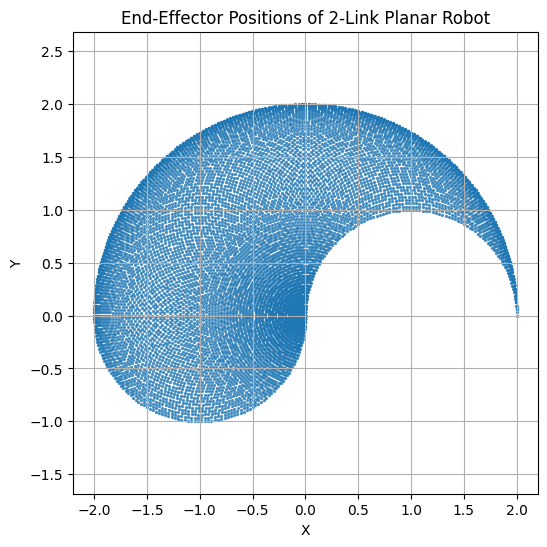

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# 2-link planar robot arm kinematics
def forward_kinematics(theta1, theta2, l1=1.0, l2=1.0):
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)
    return x, y
# Generate joint angles
theta1 = np.linspace(0, np.pi, 100)
theta2 = np.linspace(0, np.pi, 100)
X, Y = [], []
for t1 in theta1:
    for t2 in theta2:
        x, y = forward_kinematics(t1, t2)
        X.append(x)
        Y.append(y)
plt.figure(figsize=(6, 6))
plt.scatter(X, Y, s=2, alpha=0.7)
plt.title('End-Effector Positions of 2-Link Planar Robot')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True)
plt.show()

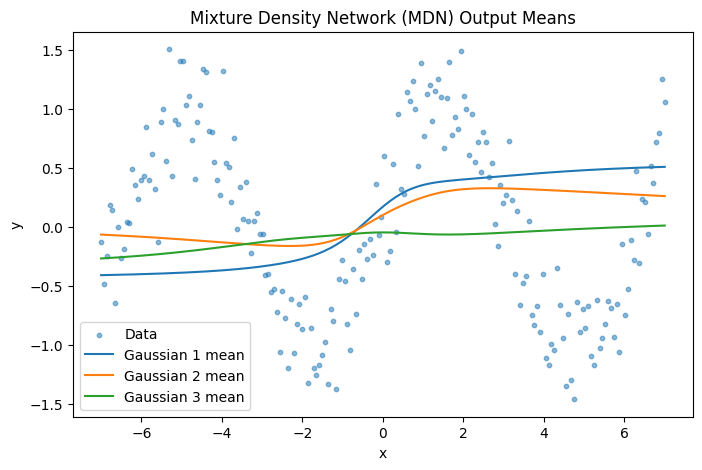

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
# Simple Mixture Density Network (MDN) for 1D regression
class MDN(nn.Module):
    def __init__(self, in_dim, out_dim, num_gaussians):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(in_dim, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh())
        self.pi = nn.Linear(32, num_gaussians)
        self.mu = nn.Linear(32, num_gaussians * out_dim)
        self.sigma = nn.Linear(32, num_gaussians * out_dim)
        self.num_gaussians = num_gaussians
        self.out_dim = out_dim
    def forward(self, x):
        h = self.fc(x)
        pi = F.softmax(self.pi(h), dim=1)
        mu = self.mu(h).view(-1, self.num_gaussians, self.out_dim)
        sigma = torch.exp(self.sigma(h)).view(-1, self.num_gaussians, self.out_dim)
        return pi, mu, sigma
# Example data: y = sin(x) + noise
np.random.seed(0)
x_data = np.linspace(-7, 7, 200).reshape(-1, 1)
y_data = np.sin(x_data) + 0.3 * np.random.randn(*x_data.shape)
x_tensor = torch.tensor(x_data, dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.float32)
# Instantiate MDN
mdn = MDN(in_dim=1, out_dim=1, num_gaussians=3)
# Forward pass (no training for demo)
pi, mu, sigma = mdn(x_tensor)
# Plot mixture means
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, s=10, label='Data', alpha=0.5)
for k in range(3):
    plt.plot(x_data, mu[:, k, 0].detach().numpy(), label=f'Gaussian {k+1} mean')
plt.title('Mixture Density Network (MDN) Output Means')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

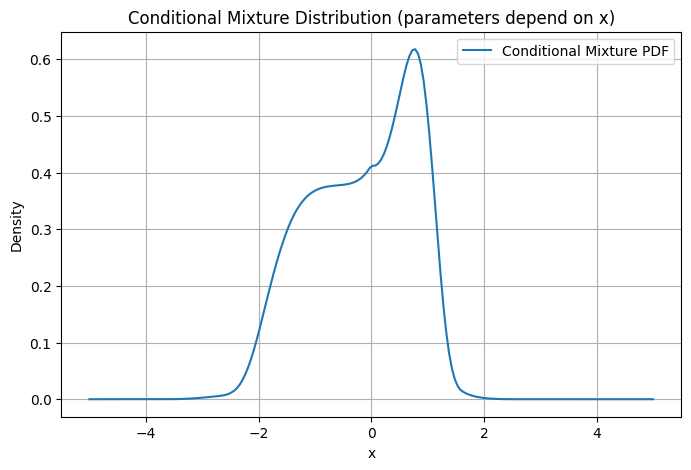

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Conditional mixture: parameters depend on x
x = np.linspace(-5, 5, 200)
# Mixture weights and means depend on x
w1 = 0.7 * (1 - np.tanh(x)) / 2
w2 = 1 - w1
mu1 = np.sin(x)
mu2 = np.cos(x)
sigma1 = 0.5 + 0.2 * np.abs(np.sin(x))
sigma2 = 0.5 + 0.2 * np.abs(np.cos(x))
# Compute mixture PDF for each x
pdf = w1 * norm.pdf(x, mu1, sigma1) + w2 * norm.pdf(x, mu2, sigma2)
plt.figure(figsize=(8, 5))
plt.plot(x, pdf, label='Conditional Mixture PDF')
plt.title('Conditional Mixture Distribution (parameters depend on x)')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

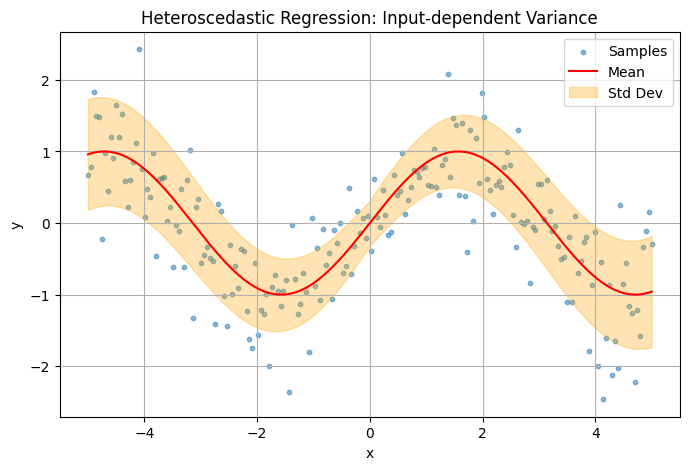

In [11]:
import numpy as np
import matplotlib.pyplot as plt
# Heteroscedastic regression: variance depends on x
x = np.linspace(-5, 5, 200)
mean = np.sin(x)
variance = 0.1 + 0.5 * (np.abs(x) / 5)
y = mean + np.random.randn(*x.shape) * np.sqrt(variance)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=10, alpha=0.5, label='Samples')
plt.plot(x, mean, color='red', label='Mean')
plt.fill_between(x, mean - np.sqrt(variance), mean + np.sqrt(variance), color='orange', alpha=0.3, label='Std Dev')
plt.title('Heteroscedastic Regression: Input-dependent Variance')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

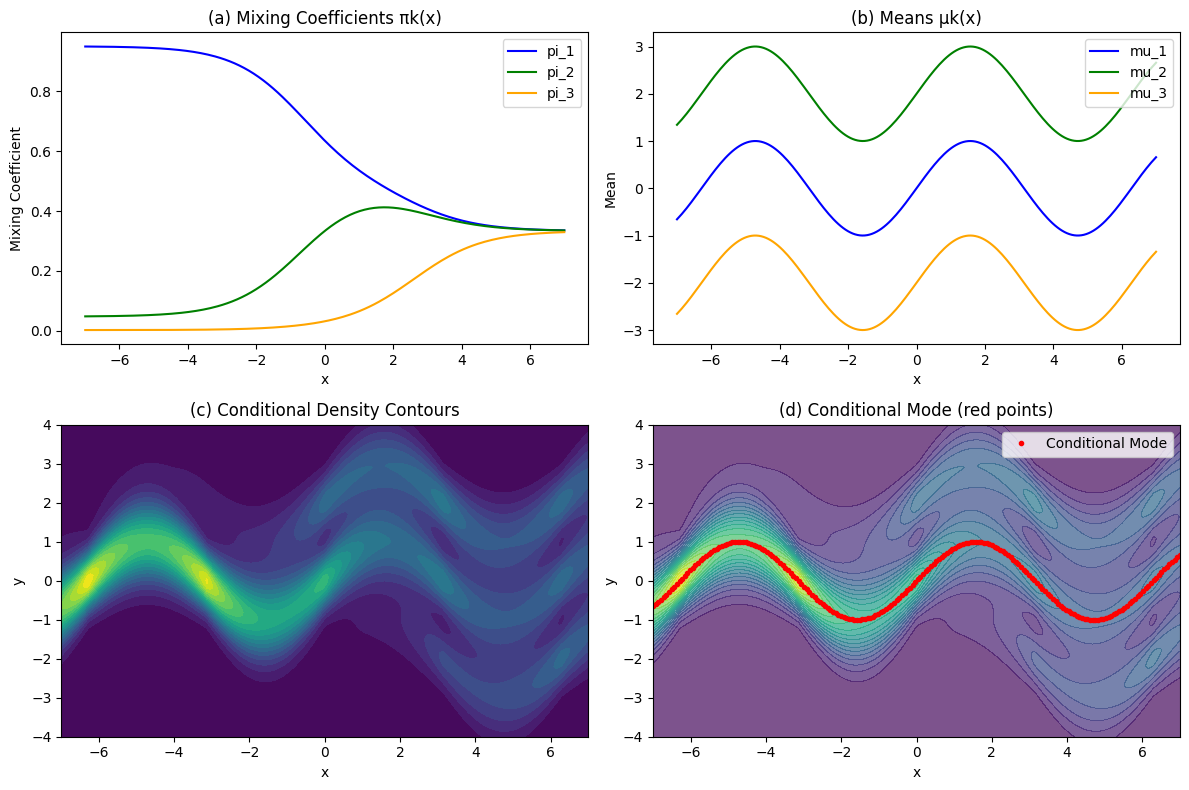

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Simulate MDN outputs for illustration
x = np.linspace(-7, 7, 200)
# (a) Mixing coefficients (pi_k(x))
pi = np.zeros((len(x), 3))
pi[:, 0] = 1 / (1 + np.exp(-(x + 3)))
pi[:, 1] = 1 / (1 + np.exp(-x))
pi[:, 2] = 1 / (1 + np.exp(-(x - 3)))
pi = pi / pi.sum(axis=1, keepdims=True)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(x, pi[:, 0], label='pi_1', color='blue')
plt.plot(x, pi[:, 1], label='pi_2', color='green')
plt.plot(x, pi[:, 2], label='pi_3', color='orange')
plt.title('(a) Mixing Coefficients πk(x)')
plt.xlabel('x')
plt.ylabel('Mixing Coefficient')
plt.legend()
# (b) Means mu_k(x)
mu = np.zeros((len(x), 3))
mu[:, 0] = np.sin(x)
mu[:, 1] = np.sin(x) + 2
mu[:, 2] = np.sin(x) - 2
plt.subplot(2, 2, 2)
plt.plot(x, mu[:, 0], label='mu_1', color='blue')
plt.plot(x, mu[:, 1], label='mu_2', color='green')
plt.plot(x, mu[:, 2], label='mu_3', color='orange')
plt.title('(b) Means μk(x)')
plt.xlabel('x')
plt.ylabel('Mean')
plt.legend()
# (c) Conditional density contours
sigma = 0.5 + 0.2 * np.abs(np.sin(x))
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
pdf = np.zeros_like(X)
for k in range(3):
    pdf += pi[:, k][None, :] * norm.pdf(Y, mu[:, k][None, :], sigma[None, :])
plt.subplot(2, 2, 3)
plt.contourf(X, Y, pdf, levels=20, cmap='viridis')
plt.title('(c) Conditional Density Contours')
plt.xlabel('x')
plt.ylabel('y')
# (d) Conditional mode (red points)
mode = np.zeros(len(x))
for i in range(len(x)):
    idx = np.argmax(pi[i])
    mode[i] = mu[i, idx]
plt.subplot(2, 2, 4)
plt.contourf(X, Y, pdf, levels=20, cmap='viridis', alpha=0.7)
plt.plot(x, mode, 'r.', label='Conditional Mode')
plt.title('(d) Conditional Mode (red points)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()